# Selection des features

In [9]:
%pip install lightgbm
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Importation des bibliothèques

In [10]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import lightgbm as lgb
from imblearn.over_sampling import SMOTE

# Preparation des donnees

In [11]:
df = pd.read_csv("../data/processed/processed_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9862 entries, 0 to 9861
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   op_unique_carrier    9862 non-null   int64  
 1   op_carrier_fl_num    9862 non-null   float64
 2   origin               9862 non-null   int64  
 3   origin_city_name     9862 non-null   int64  
 4   origin_state_nm      9862 non-null   int64  
 5   dest                 9862 non-null   int64  
 6   dest_city_name       9862 non-null   int64  
 7   dest_state_nm        9862 non-null   int64  
 8   dep_delay            9862 non-null   float64
 9   taxi_out             9862 non-null   float64
 10  taxi_in              9862 non-null   float64
 11  arr_delay            9862 non-null   float64
 12  cancelled            9862 non-null   int64  
 13  diverted             9862 non-null   int64  
 14  crs_elapsed_time     9862 non-null   float64
 15  actual_elapsed_time  9862 non-null   f

In [12]:
post_flight_features = ['dep_delay', 'nas_delay', 'carrier_delay', 'late_aircraft_delay', 'taxi_out', 'taxi_in', 'weather_delay', 'air_time', 'actual_elapsed_time', 'arr_hour', 'arr_min', 'wheels_on_hour', 'wheels_on_min', 'wheels_off_hour', 'wheels_off_min', 'security_delay', 'diverted', 'cancelled']

df_preflight = df.drop(columns=post_flight_features)

df_preflight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9862 entries, 0 to 9861
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   op_unique_carrier  9862 non-null   int64  
 1   op_carrier_fl_num  9862 non-null   float64
 2   origin             9862 non-null   int64  
 3   origin_city_name   9862 non-null   int64  
 4   origin_state_nm    9862 non-null   int64  
 5   dest               9862 non-null   int64  
 6   dest_city_name     9862 non-null   int64  
 7   dest_state_nm      9862 non-null   int64  
 8   arr_delay          9862 non-null   float64
 9   crs_elapsed_time   9862 non-null   float64
 10  distance           9862 non-null   float64
 11  fl_year            9862 non-null   int64  
 12  fl_month           9862 non-null   int64  
 13  fl_day             9862 non-null   int64  
 14  fl_dayofweek       9862 non-null   int64  
 15  is_weekend         9862 non-null   int64  
 16  season             9862 

In [13]:
# matrice des features
X = df_preflight.drop(columns=["arr_delay"], axis=1)
# variable cible -> celle que l'on veut prédire
# Transformation de la variable cible en binaire: 1 = delayed, 0 = not delayed
y = (df_preflight["arr_delay"]>0).astype(int)

## Séparation des données de test et d'entraînement

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [42]:

sm= SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
"""
#entrainer le modele
param_grid = {
    'n_estimators': [200, 500, 800],      
    'max_depth': [10, 15, 20, -1],      
    'learning_rate': [0.01, 0.05, 0.1],  
    'num_leaves': [31, 50, 100],         
    'min_child_samples': [10, 20, 50],   
    'subsample': [0.7, 0.8, 1.0],       
    'colsample_bytree': [0.7, 0.8, 1.0] 
}
"""
lgb_model= lgb.LGBMClassifier(objective='binary', random_state=42, class_weight= 'balanced')
"""
grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='recall',     
    cv=3,
    n_jobs=-1,
)

grid_search.fit(X_train_res, y_train_res)

print("Best parameters:", grid_search.best_params_)
print("Best recall (cross-val):", grid_search.best_score_)
"""

'\ngrid_search = GridSearchCV(\n    estimator=lgb_model,\n    param_grid=param_grid,\n    scoring=\'recall\',     \n    cv=3,\n    n_jobs=-1,\n)\n\ngrid_search.fit(X_train_res, y_train_res)\n\nprint("Best parameters:", grid_search.best_params_)\nprint("Best recall (cross-val):", grid_search.best_score_)\n'

[LightGBM] [Info] Number of positive: 1993, number of negative: 5403
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1935
[LightGBM] [Info] Number of data points in the train set: 7396, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Accuracy before feature selection: 0.86
              feature  importance
17        crs_dep_min    0.129667
19            dep_min    0.127000
18           dep_hour    0.093667
16       crs_dep_hour    0.085667
1   op_carrier_fl_num    0.056000
12             fl_day    0.049667
8    crs_elapsed_time    0.049333
21        crs_arr_min    0.047667
5                dest    0.042333
9            distance    0.041000
6      dest_city_name    0.037667
2              origin    0.035333
11           fl_month    0.

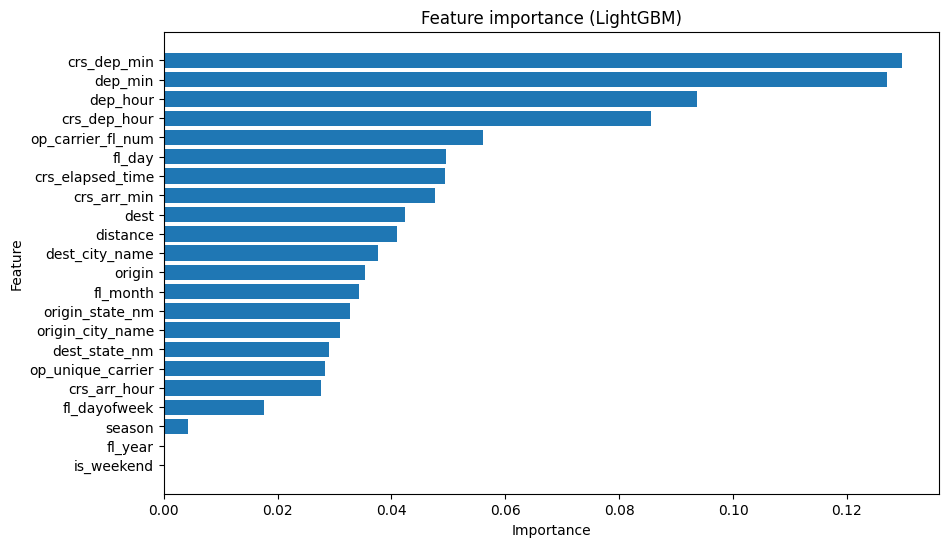

In [ ]:
lgb_model.fit(X_train, y_train)

accuracy_before = lgb_model.score(X_test, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

#Selection des features 
importances = lgb_model.feature_importances_

# Créer un DataFrame
feature_importance_df = pd.DataFrame({
    'feature': lgb_model.feature_name_,
    'importance': lgb_model.feature_importances_ / lgb_model.feature_importances_.sum()}).sort_values(by='importance', ascending = False)

print(feature_importance_df)

#Visualiser les top features 
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature importance (LightGBM)")
plt.show()

## Selection des top features 

In [ ]:
selected_features = feature_importance_df[feature_importance_df['importance'] > 0.01]['feature']

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

## Entrainement du modele LightGBM (apres selection des features)

In [41]:
lgb_model_selected = lgb.LGBMClassifier(n_estimators=100, random_state=42, class_weight = 'balanced')
lgb_model_selected.fit(X_train_selected, y_train)
y_pred = lgb_model_selected.predict(X_test_selected)

y_prob = lgb_model_selected.predict_proba(X_test_selected)[:,1]
y_pred = (y_prob > 0.35).astype(int)

accuracy_after =lgb_model_selected.score(X_test_selected, y_test)
print(f'Accuracy after feature selection: {accuracy_after:.2f}')
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))


[LightGBM] [Info] Number of positive: 1993, number of negative: 5403
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007712 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1929
[LightGBM] [Info] Number of data points in the train set: 7396, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Accuracy after feature selection: 0.86
Precision: 0.60
Recall: 0.78
Confusion Matrix: 
 [[1455  342]
 [ 149  520]]
